# SAJU ML Feature Sweep V1.3

## Goal

Explore a bounded set of interpretable saju feature families for the **Career** ranking task.

We keep the ML model fixed:

> Pairwise Logistic Regression, L2 regularized, C=0.3

Only the feature blocks change.

### Feature families

1. **TenGod**: Daewoon/Sewoon five-group Ten-God role
2. **Yongshin**: separated 용신/희신/기신/구신 fit and favorable/unfavorable supply
3. **Unseong**: 12운성 categorical state, engine raw score if available, strength interaction
4. **Shinsal**: engine-provided 신살/귀인/공망 fields when present
5. Existing **Basic / Relations** baselines

### Important

This is **DEV exploration**, not validation.

Because we compare many feature sets, the single best leaderboard score is selection-biased.
The notebook therefore also runs **nested LOSO**:

- hold out one subject
- choose the feature set using only the other subjects
- score the untouched held-out subject

That estimates whether the *feature-selection procedure itself* generalizes.

## Hard boundaries

- `OLD_DEV + Fresh A + Public DEV` only
- Career only
- Validation B never loaded
- Public CHECK never loaded
- Public FINAL never loaded
- No production wiring
- No hyperparameter sweep
- No coefficient/sign hand tuning
- Same Pairwise Logistic model for every feature set

In [1]:
from pathlib import Path
from itertools import product
from collections import Counter, defaultdict
import json
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

SEED = 20260815
TARGET_DOMAIN = "Career"

# Exploratory repeated CV
N_REPEATS = 50
N_FOLDS = 5

# Nested LOSO inner selection
INNER_REPEATS = 10
INNER_FOLDS = 5

STRICT_BIRTH_TIME = True

def find_repo_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for candidate in [p, *p.parents]:
        if (candidate / "saju_engine.py").exists():
            return candidate
    raise FileNotFoundError(
        "Could not find repo root containing saju_engine.py. "
        "Run this notebook from inside the Chartpalja saju repo."
    )

REPO_ROOT = find_repo_root()
DATA_DIR = REPO_ROOT / "research" / "ml_corpus" / "v1"
V1_ARTIFACT_DIR = REPO_ROOT / "research" / "ml" / "artifacts" / "v1"
ARTIFACT_DIR = REPO_ROOT / "research" / "ml" / "artifacts" / "v1_3"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print("repo:", REPO_ROOT)
print("artifacts:", ARTIFACT_DIR)

repo: /Users/sangjinlee/Desktop/projects/saju
artifacts: /Users/sangjinlee/Desktop/projects/saju/research/ml/artifacts/v1_3


## Load corpus, engine inputs, and V1 feature cache

In [2]:
corpus = json.load(open(DATA_DIR / "SAJU_ML_CORPUS_V1.json", encoding="utf-8"))
engine_inputs = json.load(open(DATA_DIR / "SAJU_ML_ENGINE_INPUTS_V1.json", encoding="utf-8"))

pq = V1_ARTIFACT_DIR / "ml_feature_table_v1.parquet"
csv = V1_ARTIFACT_DIR / "ml_feature_table_v1.csv"

if pq.exists():
    v1_features = pd.read_parquet(pq)
elif csv.exists():
    v1_features = pd.read_csv(csv)
else:
    raise FileNotFoundError(
        "Run saju_ml_research_v1.ipynb first so ml_feature_table_v1 exists."
    )

assert corpus["source_pools"] == {"OLD_DEV": 56, "FRESH_A": 14, "PUBLIC_DEV": 24}
assert all(s["source_pool"] not in {"VALIDATION_B", "PUBLIC_CHECK", "PUBLIC_FINAL"}
           for s in corpus["subjects"])

subject_by_id = {s["subject_id"]: s for s in corpus["subjects"]}
engine_input_by_id = {s["subject_id"]: s for s in engine_inputs["subjects"]}

print("subjects:", len(subject_by_id))
print("V1 feature rows:", len(v1_features))

subjects: 94
V1 feature rows: 341


## Build Career subject-year labels

In [3]:
def build_target_rows(domain):
    raw = []
    for s in corpus["subjects"]:
        if STRICT_BIRTH_TIME and not s["birth"]["birth_time_known"]:
            continue
        for e in s["events"]:
            if not e["ml_usable"]:
                continue
            lab = e["targets"].get(domain, "unknown")
            if lab not in {"positive", "negative"}:
                continue
            raw.append({
                "subject_id": s["subject_id"],
                "name": s["name"],
                "source_pool": s["source_pool"],
                "year": int(e["year"]),
                "label": 1 if lab == "positive" else 0,
                "event_id": e["event_id"],
            })

    raw_df = pd.DataFrame(raw)
    rows, collisions = [], []
    for (sid, year), g in raw_df.groupby(["subject_id", "year"]):
        if g["label"].nunique() > 1:
            collisions.append((sid, int(year), list(g["event_id"])))
            continue
        rows.append({
            "subject_id": sid,
            "name": g["name"].iloc[0],
            "source_pool": g["source_pool"].iloc[0],
            "year": int(year),
            "label": int(g["label"].iloc[0]),
        })
    return pd.DataFrame(rows), collisions

target_rows, collisions = build_target_rows(TARGET_DOMAIN)

pairable_subjects = []
for sid, g in target_rows.groupby("subject_id"):
    if set(g["label"]) == {0, 1}:
        pairable_subjects.append(sid)

target_rows = target_rows[target_rows["subject_id"].isin(pairable_subjects)].copy()

print("Career subject-years:", len(target_rows))
print("pair-evaluable subjects:", len(pairable_subjects))
print("positive / negative:",
      int(target_rows["label"].sum()),
      int((1-target_rows["label"]).sum()))
print("colliding years removed:", len(collisions))

Career subject-years: 113
pair-evaluable subjects: 23
positive / negative: 75 38
colliding years removed: 2


## Recompute engine context for additional feature families

This reuses the same production-compatible birth adapter used in V1.

In [4]:
import sys
from datetime import datetime

sys.path.insert(0, str(REPO_ROOT))
import saju_engine as se
import sajupy

def parse_utc_offset(raw):
    if isinstance(raw, (int, float)):
        return float(raw)
    s = str(raw).strip()
    sign = -1.0 if s.startswith("-") else 1.0
    s = s[1:] if s[:1] in "+-" else s
    hh, mm = s.split(":")
    return sign * (int(hh) + int(mm) / 60.0)

def public_lon_corrected_birth(public_birth):
    y, m, d = map(int, public_birth["date"].split("-"))
    hh, mi = map(int, public_birth["time"].split(":")[:2])
    lon = float(public_birth["longitude"])
    utc_hours = parse_utc_offset(public_birth["utc_offset"])

    calc = sajupy.get_saju_calculator()
    civil = datetime(y, m, d, hh, mi)
    corr = float(calc._calculate_solar_time_correction(lon, utc_hours))
    h2, min2, dc = calc._adjust_time_for_solar(civil.hour, civil.minute, corr)
    y2, m2, d2 = calc._adjust_date_for_solar(
        civil.year, civil.month, civil.day, dc
    )
    return {
        "calendar": public_birth.get("calendar", "solar"),
        "y": y2, "m": m2, "d": d2,
        "h": h2, "min": min2,
    }

def get_engine_birth(subject_id):
    rec = engine_input_by_id[subject_id]
    if rec["mode"] == "frozen_engine_birth":
        return dict(rec["engine_birth"])
    if rec["mode"] == "public_runtime_longitude_correction":
        return public_lon_corrected_birth(rec["public_birth"])
    raise ValueError(rec["mode"])

def compute_subject_engine(subject_id):
    s = subject_by_id[subject_id]
    b = get_engine_birth(subject_id)
    inp = se.BirthInput(
        year=int(b["y"]), month=int(b["m"]), day=int(b["d"]),
        hour=int(b["h"]), minute=int(b["min"]),
        gender=s["gender"],
        calendar=b.get("calendar", "solar"),
        is_leap_month=False,
        use_solar_time=False,
        utc_offset=9,
    )
    result = se.compute_all(inp)
    daewoon = se.build_daewoon_detail(result)
    timeline = result["chart_data"]["연도별_타임라인"]
    meta = {int(x["year"]): x for x in timeline}
    return result, daewoon, meta

engine_cache = {}
for i, sid in enumerate(sorted(pairable_subjects), 1):
    engine_cache[sid] = compute_subject_engine(sid)
    if i % 5 == 0:
        print(f"engine {i}/{len(pairable_subjects)}")

[SAJU_DEBUG] original_input: 1955-10-28 22:07
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=male
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1955-10-28
[SAJU_DEBUG] final_datetime(KST): 1955-10-28T22:07:00+09:00
[SAJU_DEBUG] pillars: 연=乙未 월=丙戌 일=壬戌 시=辛亥
[SAJU_DEBUG] original_input: 1963-06-09 07:57
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=male
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1963-06-09
[SAJU_DEBUG] final_datetime(KST): 1963-06-09T07:57:00+09:00
[SAJU_DEBUG] pillars: 연=癸卯 월=戊午 일=癸未 시=丙辰
[SAJU_DEBUG] original_input: 1941-08-03 12:30
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=female
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1941-08-03
[SAJU_DEBUG] final_datetime(KST): 1941-08-03T12:30:00+09:00
[SAJU_DEBUG] pillars: 연=辛巳 월=乙未 일=癸未 시=戊午
[SAJU_DEBUG] original_input: 1963-02-17 13:30
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=male
[S

engine 5/23


[SAJU_DEBUG] original_input: 1981-08-08 07:04
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=male
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1981-08-08
[SAJU_DEBUG] final_datetime(KST): 1981-08-08T07:04:00+09:00
[SAJU_DEBUG] 반시보정: 丙辰→乙卯 (07:04)
[SAJU_DEBUG] pillars: 연=辛酉 월=丙申 일=戊午 시=乙卯
[SAJU_DEBUG] original_input: 1946-06-14 09:59
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=male
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1946-06-14
[SAJU_DEBUG] final_datetime(KST): 1946-06-14T09:59:00+09:00
[SAJU_DEBUG] pillars: 연=丙戌 월=甲午 일=己未 시=己巳
[SAJU_DEBUG] original_input: 1961-08-04 18:46
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=male
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1961-08-04
[SAJU_DEBUG] final_datetime(KST): 1961-08-04T18:46:00+09:00
[SAJU_DEBUG] pillars: 연=辛丑 월=乙未 일=己巳 시=癸酉
[SAJU_DEBUG] original_input: 1994-03-01 00:18
[SAJU_DEBUG] calendar=solar, is_l

engine 10/23


[SAJU_DEBUG] original_input: 1961-05-12 23:14
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=male
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1961-05-12
[SAJU_DEBUG] final_datetime(KST): 1961-05-12T23:14:00+09:00
[SAJU_DEBUG] 반시보정: 戊子→己亥 (23:14)
[SAJU_DEBUG] pillars: 연=辛丑 월=癸巳 일=丙午 시=己亥
[SAJU_DEBUG] original_input: 1948-09-17 07:11
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=male
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1948-09-17
[SAJU_DEBUG] final_datetime(KST): 1948-09-17T07:11:00+09:00
[SAJU_DEBUG] 반시보정: 庚辰→己卯 (07:11)
[SAJU_DEBUG] pillars: 연=戊子 월=辛酉 일=乙巳 시=己卯
[SAJU_DEBUG] original_input: 1960-12-18 22:01
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=male
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1960-12-18
[SAJU_DEBUG] final_datetime(KST): 1960-12-18T22:01:00+09:00
[SAJU_DEBUG] pillars: 연=庚子 월=戊子 일=庚辰 시=丁亥
[SAJU_DEBUG] original_input: 1985-10-25 00:30


engine 15/23


[SAJU_DEBUG] original_input: 1953-11-20 02:40
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=male
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1953-11-20
[SAJU_DEBUG] final_datetime(KST): 1953-11-20T02:40:00+09:00
[SAJU_DEBUG] pillars: 연=癸巳 월=癸亥 일=乙亥 시=丁丑
[SAJU_DEBUG] original_input: 1970-07-14 05:58
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=male
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1970-07-14
[SAJU_DEBUG] final_datetime(KST): 1970-07-14T05:58:00+09:00
[SAJU_DEBUG] pillars: 연=庚戌 월=癸未 일=乙未 시=己卯
[SAJU_DEBUG] original_input: 1987-06-24 19:25
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=male
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1987-06-24
[SAJU_DEBUG] final_datetime(KST): 1987-06-24T19:25:00+09:00
[SAJU_DEBUG] 반시보정: 甲戌→癸酉 (19:25)
[SAJU_DEBUG] pillars: 연=丁卯 월=丙午 일=甲辰 시=癸酉
[SAJU_DEBUG] original_input: 1942-11-24 03:12
[SAJU_DEBUG] calendar=solar, is_l

engine 20/23


[SAJU_DEBUG] original_input: 1946-03-05 08:21
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=male
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1946-03-05
[SAJU_DEBUG] final_datetime(KST): 1946-03-05T08:21:00+09:00
[SAJU_DEBUG] pillars: 연=丙戌 월=庚寅 일=戊寅 시=丙辰
[SAJU_DEBUG] original_input: 1908-06-26 01:26
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=male
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1908-06-26
[SAJU_DEBUG] final_datetime(KST): 1908-06-26T01:26:00+09:00
[SAJU_DEBUG] 반시보정: 辛丑→庚子 (01:26)
[SAJU_DEBUG] pillars: 연=戊申 월=戊午 일=壬子 시=庚子


## Helpers: pillars, Yongshin, 12운성, Shinsal

### Yongshin

Use the engine's existing `_check_yongshin_fit` and keep the components separate:

- 용신
- 희신
- 기신
- 구신
- favorable/unfavorable element supply

No hardcoded `용신=good` coefficient is imposed. The model learns the sign.

### 12운성

Use categorical states. If the engine exposes `_UNSEONG_SCORE`, also include its raw score and a strength interaction.

### Shinsal

Use only engine-produced fields whose key path explicitly contains:

- `신살`
- `귀인`
- `공망`

No manually invented 신살 score is added.

In [5]:
STEMS = list("甲乙丙丁戊己庚辛壬癸")
BRANCHES = list("子丑寅卯辰巳午未申酉戌亥")
UNSEONG_STATES = [
    "장생","목욕","관대","건록","제왕","쇠",
    "병","사","묘","절","태","양"
]

STEM_ELEMENT = getattr(se, "STEM_ELEMENT", {
    "甲":"목","乙":"목","丙":"화","丁":"화","戊":"토",
    "己":"토","庚":"금","辛":"금","壬":"수","癸":"수"
})
BRANCH_ELEMENT = getattr(se, "BRANCH_ELEMENT_MAIN", {
    "子":"수","丑":"토","寅":"목","卯":"목","辰":"토","巳":"화",
    "午":"화","未":"토","申":"금","酉":"금","戌":"토","亥":"수"
})

def pillar_chars(value):
    if isinstance(value, (list, tuple)) and len(value) >= 2:
        a, b = str(value[0]), str(value[1])
        if a in STEMS and b in BRANCHES:
            return a, b
    s = str(value)
    st = next((x for x in s if x in STEMS), None)
    br = next((x for x in s if x in BRANCHES), None)
    return st, br

def sexagenary_year_pillar(year):
    i = (int(year) - 1984) % 60
    return STEMS[i % 10] + BRANCHES[i % 12]

def get_daewoon_row(daewoon, year):
    for row in daewoon:
        if int(row["start_year"]) <= int(year) < int(row["end_year"]):
            return row
    return None

def get_sewoon_pillar(meta_row, year):
    for key in ("세운_pillar", "세운", "연주", "year_pillar"):
        if meta_row.get(key):
            st, br = pillar_chars(meta_row[key])
            if st and br:
                return st + br
    return sexagenary_year_pillar(year)

# Classical categorical fallback, used only if the engine does not provide an accessible helper.
UNSEONG_START = {
    "甲":"亥", "乙":"午",
    "丙":"寅", "丁":"酉",
    "戊":"寅", "己":"酉",
    "庚":"巳", "辛":"子",
    "壬":"申", "癸":"卯",
}
YANG_STEMS = set("甲丙戊庚壬")

def local_twelve_unseong(day_stem, branch):
    start = UNSEONG_START[day_stem]
    start_i = BRANCHES.index(start)
    branch_i = BRANCHES.index(branch)
    direction = 1 if day_stem in YANG_STEMS else -1
    steps = ((branch_i - start_i) * direction) % 12
    return UNSEONG_STATES[steps]

def get_unseong_state(day_stem, branch):
    # Prefer engine helpers when their signatures match.
    for fn_name in ("twelve_unseong", "_twelve_unseong"):
        fn = getattr(se, fn_name, None)
        if fn is None:
            continue
        for args in ((day_stem, branch), (branch, day_stem)):
            try:
                v = fn(*args)
                if isinstance(v, str) and v in UNSEONG_STATES:
                    return v
            except Exception:
                pass
    return local_twelve_unseong(day_stem, branch)

def strength_bucket(result):
    x = result.get("신강신약") or {}
    verdict = x.get("판정") if isinstance(x, dict) else str(x)
    verdict = verdict or ""
    if any(k in verdict for k in ("신강","태강","극왕")):
        return "strong"
    if any(k in verdict for k in ("신약","태약","극약")):
        return "weak"
    return "neutral"

def yongshin_block_features(result, stem, branch, prefix):
    out = {}
    yong = result.get("용신") or {}
    day_stem = (result.get("원국") or {}).get("day", ["",""])[0]

    fit = {}
    if yong and day_stem and hasattr(se, "_check_yongshin_fit"):
        try:
            fit = se._check_yongshin_fit(stem, branch, yong, day_stem) or {}
        except Exception:
            fit = {}

    for src, dst in [
        ("용신부합","yong_fit"),
        ("희신부합","hee_fit"),
        ("기신부합","gi_fit"),
        ("구신부합","gu_fit"),
        ("용신부합_천간","yong_stem_fit"),
        ("용신부합_지지","yong_branch_fit"),
    ]:
        out[f"yongshin__{prefix}_{dst}"] = float(fit.get(src) or 0.0)

    yong_e = yong.get("용신_오행") or ""
    hee = set(yong.get("희신_오행") or [])
    gi = set(yong.get("기신_오행") or [])
    gu = set(yong.get("구신_오행") or [])

    fav = ({yong_e} | hee) - {""}
    unfav = (gi | gu) - {""}

    stem_e = STEM_ELEMENT.get(stem, "")
    branch_e = BRANCH_ELEMENT.get(branch, "")

    out[f"yongshin__{prefix}_supplies_fav"] = float(
        stem_e in fav or branch_e in fav
    )
    out[f"yongshin__{prefix}_supplies_unfav"] = float(
        stem_e in unfav or branch_e in unfav
    )
    return out

def unseong_block_features(result, branch, prefix):
    out = {}
    day_stem = (result.get("원국") or {}).get("day", ["",""])[0]
    state = get_unseong_state(day_stem, branch)

    for st in UNSEONG_STATES:
        out[f"unseong__{prefix}_state_{st}"] = float(state == st)

    raw_map = getattr(se, "_UNSEONG_SCORE", {})
    raw_score = float(raw_map.get(state, 0.0)) if isinstance(raw_map, dict) else 0.0
    out[f"unseong__{prefix}_raw_score"] = raw_score

    bucket = strength_bucket(result)
    sign = 1.0 if bucket == "weak" else (-1.0 if bucket == "strong" else 0.0)
    out[f"unseong__{prefix}_score_x_strength"] = raw_score * sign
    return out

SHINSAL_KEYWORDS = ("신살", "귀인", "공망")

def flatten_selected(obj, prefix="", out=None):
    if out is None:
        out = {}
    if isinstance(obj, dict):
        for k, v in obj.items():
            path = f"{prefix}.{k}" if prefix else str(k)
            if any(token in path for token in SHINSAL_KEYWORDS):
                flatten_all(v, path, out)
            elif isinstance(v, (dict, list, tuple)):
                flatten_selected(v, path, out)
    elif isinstance(obj, (list, tuple)):
        for i, v in enumerate(obj):
            flatten_selected(v, f"{prefix}[{i}]", out)
    return out

def safe_name(s):
    return re.sub(r"[^0-9A-Za-z가-힣_]+", "_", str(s))[:120]

def flatten_all(v, path, out):
    key = safe_name(path)
    if isinstance(v, bool):
        out[f"shinsal__{key}"] = float(v)
    elif isinstance(v, (int, float)) and np.isfinite(v):
        out[f"shinsal__{key}"] = float(v)
    elif isinstance(v, str):
        if v.strip():
            out[f"shinsal__{key}__{safe_name(v)}"] = 1.0
    elif isinstance(v, dict):
        for k2, v2 in v.items():
            flatten_all(v2, f"{path}.{k2}", out)
    elif isinstance(v, (list, tuple, set)):
        out[f"shinsal__{key}__count"] = float(len(v))
        for item in v:
            if isinstance(item, str):
                out[f"shinsal__{key}__{safe_name(item)}"] = 1.0
            elif isinstance(item, dict):
                flatten_all(item, path, out)

def shinsal_features(dw_row, meta_row):
    out = {}

    # Explicit Daewoon engine components
    if dw_row:
        bd = dw_row.get("breakdown") or {}
        if "shinsal" in bd:
            out["shinsal__dw_breakdown_scalar"] = float(bd.get("shinsal") or 0.0)

        gm = dw_row.get("gongmang_factors") or {}
        for k, v in gm.items():
            if isinstance(v, (int, float)):
                out[f"shinsal__dw_gongmang_{safe_name(k)}"] = float(v)

        ind = dw_row.get("indicators") or {}
        noble = ind.get("귀인력")
        if isinstance(noble, (int, float)):
            out["shinsal__dw_noble_power"] = float(noble)

        flatten_selected(dw_row, "dw", out)

    # Annual timeline fields if the production engine exports them.
    flatten_selected(meta_row, "sw", out)
    return out

## Build extended feature table

In [6]:
extended_rows = []

for i, sid in enumerate(sorted(pairable_subjects), 1):
    result, daewoon, meta = engine_cache[sid]

    for year in sorted(target_rows.loc[target_rows["subject_id"] == sid, "year"].unique()):
        year = int(year)
        if year not in meta:
            continue

        m = meta[year]
        dw_row = get_daewoon_row(daewoon, year)
        if not dw_row:
            continue

        dw_stem, dw_branch = pillar_chars(
            dw_row.get("daewoon_pillar") or dw_row.get("ganzhi")
        )
        sw_stem, sw_branch = pillar_chars(get_sewoon_pillar(m, year))

        if not all([dw_stem, dw_branch, sw_stem, sw_branch]):
            continue

        f = {"subject_id": sid, "year": year}
        f.update(yongshin_block_features(result, dw_stem, dw_branch, "dw"))
        f.update(yongshin_block_features(result, sw_stem, sw_branch, "sw"))
        f.update(unseong_block_features(result, dw_branch, "dw"))
        f.update(unseong_block_features(result, sw_branch, "sw"))
        f.update(shinsal_features(dw_row, m))

        extended_rows.append(f)

    if i % 5 == 0:
        print(f"extended features {i}/{len(pairable_subjects)}")

extended_df = pd.DataFrame(extended_rows).fillna(0.0)

# Merge V1 + extended + labels
model_df = (
    target_rows
    .merge(v1_features, on=["subject_id","year"], how="inner", validate="one_to_one")
    .merge(extended_df, on=["subject_id","year"], how="inner", validate="one_to_one")
)

print("rows:", len(model_df))
print("subjects:", model_df["subject_id"].nunique())

block_counts = {
    "basic": len([c for c in model_df if c.startswith("basic__")]),
    "tengod": len([c for c in model_df if c.startswith("tengod__")]),
    "relations": len([c for c in model_df if c.startswith("relation__")]),
    "yongshin": len([c for c in model_df if c.startswith("yongshin__")]),
    "unseong": len([c for c in model_df if c.startswith("unseong__")]),
    "shinsal": len([c for c in model_df if c.startswith("shinsal__")]),
}
print(block_counts)

# Remove extended columns with zero variance.
for prefix in ("yongshin__", "unseong__", "shinsal__"):
    cols = [c for c in model_df if c.startswith(prefix)]
    drop = [c for c in cols if model_df[c].nunique(dropna=False) <= 1]
    if drop:
        model_df = model_df.drop(columns=drop)
        print(prefix, "dropped zero-variance:", len(drop))

extended_df.to_csv(ARTIFACT_DIR / "extended_astrology_features_v1_3.csv", index=False)

extended features 5/23
extended features 10/23
extended features 15/23
extended features 20/23
rows: 113
subjects: 23
{'basic': 166, 'tengod': 10, 'relations': 21, 'yongshin': 16, 'unseong': 28, 'shinsal': 43}


## Coverage audit

Do not interpret a weak Shinsal result if the engine exports almost no varying Shinsal information at annual level.

In [7]:
feature_coverage = []
for prefix in ("yongshin__", "unseong__", "shinsal__"):
    for c in [x for x in model_df if x.startswith(prefix)]:
        vals = pd.to_numeric(model_df[c], errors="coerce").fillna(0.0)
        feature_coverage.append({
            "feature": c,
            "nonzero_rows": int((vals != 0).sum()),
            "nonzero_share": float((vals != 0).mean()),
            "n_unique": int(vals.nunique()),
        })

coverage_df = pd.DataFrame(feature_coverage)
display(
    coverage_df.groupby(
        coverage_df["feature"].str.split("__").str[0]
    ).agg(
        n_features=("feature","size"),
        median_nonzero_share=("nonzero_share","median"),
        max_nonzero_share=("nonzero_share","max"),
    )
)
coverage_df.to_csv(ARTIFACT_DIR / "feature_coverage_v1_3.csv", index=False)

,n_features,median_nonzero_share,max_nonzero_share
feature,,,
shinsal,43,0.176991,1.000000
unseong,28,0.092920,0.955752
yongshin,16,0.676991,0.884956


## Fixed feature combinations

This is deliberately bounded. We do not enumerate every mathematical subset.

The key questions are marginal:

- Does Yongshin add beyond TenGod?
- Does 12운성 add beyond TenGod?
- Does Shinsal add beyond TenGod?
- Do Yongshin + 12운성 work together?
- Does the full traditional block beat the simpler model?

In [8]:
basic = sorted([c for c in model_df if c.startswith("basic__")])
tg = sorted([c for c in model_df if c.startswith("tengod__")])
rel = sorted([c for c in model_df if c.startswith("relation__")])
yong = sorted([c for c in model_df if c.startswith("yongshin__")])
uns = sorted([c for c in model_df if c.startswith("unseong__")])
shin = sorted([c for c in model_df if c.startswith("shinsal__")])

FEATURE_SETS = {
    "TENGOD": tg,
    "YONGSHIN": yong,
    "UNSEONG": uns,
    "SHINSAL": shin,

    "TENGOD+YONGSHIN": tg + yong,
    "TENGOD+UNSEONG": tg + uns,
    "TENGOD+SHINSAL": tg + shin,

    "YONGSHIN+UNSEONG": yong + uns,
    "YONGSHIN+SHINSAL": yong + shin,
    "UNSEONG+SHINSAL": uns + shin,

    "TENGOD+YONGSHIN+UNSEONG": tg + yong + uns,
    "TENGOD+YONGSHIN+SHINSAL": tg + yong + shin,
    "TENGOD+UNSEONG+SHINSAL": tg + uns + shin,

    "ALL_TRADITIONAL_4": tg + yong + uns + shin,

    "BASIC+TENGOD": basic + tg,
    "BASIC+TENGOD+RELATIONS": basic + tg + rel,
    "ALL_WITH_BASIC_RELATIONS": basic + tg + rel + yong + uns + shin,
}

# Drop empty feature sets, possible only if engine exports no Shinsal variables.
FEATURE_SETS = {k: sorted(set(v)) for k, v in FEATURE_SETS.items() if len(set(v)) > 0}

for k, v in FEATURE_SETS.items():
    print(f"{k:32s} {len(v):4d}")

TENGOD                             10
YONGSHIN                           16
UNSEONG                            28
SHINSAL                            43
TENGOD+YONGSHIN                    26
TENGOD+UNSEONG                     38
TENGOD+SHINSAL                     53
YONGSHIN+UNSEONG                   44
YONGSHIN+SHINSAL                   59
UNSEONG+SHINSAL                    71
TENGOD+YONGSHIN+UNSEONG            54
TENGOD+YONGSHIN+SHINSAL            69
TENGOD+UNSEONG+SHINSAL             81
ALL_TRADITIONAL_4                  97
BASIC+TENGOD                      176
BASIC+TENGOD+RELATIONS            197
ALL_WITH_BASIC_RELATIONS          284


## Pairwise Logistic model and subject-level metrics

In [9]:
MODEL = Pipeline([
    ("scale", StandardScaler()),
    ("model", LogisticRegression(
        penalty="l2",
        C=0.3,
        max_iter=3000,
        random_state=SEED,
    )),
])

def make_pairwise_training(df, cols):
    Xs, ys = [], []
    for sid, g in df.groupby("subject_id"):
        pos = g[g["label"] == 1]
        neg = g[g["label"] == 0]
        if pos.empty or neg.empty:
            continue
        for _, p in pos.iterrows():
            for _, n in neg.iterrows():
                diff = p[cols].to_numpy(float) - n[cols].to_numpy(float)
                Xs.append(diff);  ys.append(1)
                Xs.append(-diff); ys.append(0)
    return np.asarray(Xs), np.asarray(ys)

def subject_pairwise_rows(df, score_col):
    rows = []
    for sid, g in df.groupby("subject_id"):
        pos = g.loc[g["label"] == 1, score_col].dropna().to_numpy(float)
        neg = g.loc[g["label"] == 0, score_col].dropna().to_numpy(float)
        if len(pos) == 0 or len(neg) == 0:
            continue

        vals = [
            1.0 if p > n else 0.5 if p == n else 0.0
            for p, n in product(pos, neg)
        ]
        rows.append({
            "subject_id": sid,
            "pairwise": float(np.mean(vals)),
            "hit": float(np.mean(pos) > np.mean(neg)),
            "sep": float(np.mean(pos) - np.mean(neg)),
        })
    return pd.DataFrame(rows)

def aggregate(sdf):
    return {
        "n_subjects": len(sdf),
        "macro_pairwise": float(sdf["pairwise"].mean()),
        "subject_hit_rate": float(sdf["hit"].mean()),
        "median_sep": float(sdf["sep"].median()),
    }

control_subject = subject_pairwise_rows(model_df, "baseline__control_score")
control_metrics = aggregate(control_subject)
print("Production Control:", control_metrics)

Production Control: {'n_subjects': 23, 'macro_pairwise': 0.48454106280193243, 'subject_hit_rate': 0.4782608695652174, 'median_sep': -1.3333333333333428}


## Exploratory repeated randomized subject CV

In [10]:
def subject_folds(subject_ids, n_folds, seed):
    ids = np.array(sorted(subject_ids), dtype=object)
    rng = np.random.default_rng(seed)
    rng.shuffle(ids)
    return [list(x) for x in np.array_split(ids, n_folds)]

def cv_once(df, cols, seed, n_folds=N_FOLDS):
    pred = pd.Series(np.nan, index=df.index, dtype=float)
    folds = subject_folds(df["subject_id"].unique(), n_folds, seed)

    for test_subjects in folds:
        test_mask = df["subject_id"].isin(test_subjects)
        train_df = df[~test_mask]
        test_df = df[test_mask]

        Xp, yp = make_pairwise_training(train_df, cols)
        m = clone(MODEL)
        m.fit(Xp, yp)

        scaler = m.named_steps["scale"]
        clf = m.named_steps["model"]
        Xte = scaler.transform(test_df[cols].to_numpy(float))
        pred.loc[test_df.index] = Xte @ clf.coef_.ravel()

    out = df[["subject_id","year","label"]].copy()
    out["score"] = pred
    return aggregate(subject_pairwise_rows(out, "score"))

repeat_rows = []

for fs_name, cols in FEATURE_SETS.items():
    for r in range(N_REPEATS):
        metrics = cv_once(model_df, cols, SEED + r)
        repeat_rows.append({
            "feature_set": fs_name,
            "repeat": r,
            **metrics,
        })

repeat_df = pd.DataFrame(repeat_rows)

summary = repeat_df.groupby("feature_set").agg(
    pairwise_mean=("macro_pairwise","mean"),
    pairwise_median=("macro_pairwise","median"),
    pairwise_p10=("macro_pairwise", lambda x: np.quantile(x, 0.10)),
    pairwise_p90=("macro_pairwise", lambda x: np.quantile(x, 0.90)),
    hit_mean=("subject_hit_rate","mean"),
    hit_p10=("subject_hit_rate", lambda x: np.quantile(x, 0.10)),
    hit_p90=("subject_hit_rate", lambda x: np.quantile(x, 0.90)),
).sort_values("pairwise_mean", ascending=False)

summary["vs_control"] = summary["pairwise_mean"] - control_metrics["macro_pairwise"]

display(summary)
summary.to_csv(ARTIFACT_DIR / "career_feature_sweep_summary_v1_3.csv")
repeat_df.to_csv(ARTIFACT_DIR / "career_feature_sweep_repeats_v1_3.csv", index=False)

,pairwise_mean,pairwise_median,pairwise_p10,pairwise_p90,hit_mean,hit_p10,hit_p90,vs_control
feature_set,,,,,,,,
TENGOD,0.601916,0.610455,0.558609,0.641580,0.631304,0.565217,0.695652,0.117375
SHINSAL,0.582048,0.578968,0.538982,0.642378,0.569565,0.517391,0.652174,0.097507
YONGSHIN+SHINSAL,0.578237,0.573102,0.537495,0.622778,0.617391,0.521739,0.695652,0.093696
BASIC+TENGOD,0.573493,0.575017,0.523958,0.636649,0.642609,0.560870,0.739130,0.088952
YONGSHIN,0.566574,0.571929,0.501108,0.630135,0.642609,0.565217,0.739130,0.082033
TENGOD+YONGSHIN+UNSEONG,0.566121,0.569945,0.504369,0.633509,0.624348,0.521739,0.700000,0.081580
TENGOD+SHINSAL,0.555839,0.552329,0.483244,0.629482,0.593043,0.517391,0.695652,0.071297
YONGSHIN+UNSEONG,0.551685,0.548982,0.483137,0.609600,0.605217,0.521739,0.695652,0.067144
ALL_TRADITIONAL_4,0.550294,0.554106,0.489541,0.607029,0.591304,0.521739,0.695652,0.065753


## Fixed-combination LOSO

Each combination is also evaluated with Leave-One-Subject-Out.
This removes fold randomness, but the leaderboard is still exploratory because many combinations are compared.

In [11]:
def loso_predict(df, cols):
    pred = pd.Series(np.nan, index=df.index, dtype=float)

    for held_out in sorted(df["subject_id"].unique()):
        train_df = df[df["subject_id"] != held_out]
        test_df = df[df["subject_id"] == held_out]

        Xp, yp = make_pairwise_training(train_df, cols)
        m = clone(MODEL)
        m.fit(Xp, yp)

        scaler = m.named_steps["scale"]
        clf = m.named_steps["model"]
        Xte = scaler.transform(test_df[cols].to_numpy(float))
        pred.loc[test_df.index] = Xte @ clf.coef_.ravel()

    out = df[["subject_id","year","label"]].copy()
    out["score"] = pred
    return out

loso_rows = []
loso_predictions = {}

for name, cols in FEATURE_SETS.items():
    pred = loso_predict(model_df, cols)
    loso_predictions[name] = pred
    metrics = aggregate(subject_pairwise_rows(pred, "score"))
    loso_rows.append({"feature_set": name, **metrics})

loso_summary = pd.DataFrame(loso_rows).sort_values(
    "macro_pairwise", ascending=False
)
loso_summary["vs_control"] = (
    loso_summary["macro_pairwise"] - control_metrics["macro_pairwise"]
)

display(loso_summary)
loso_summary.to_csv(
    ARTIFACT_DIR / "career_feature_sweep_loso_v1_3.csv",
    index=False
)

,feature_set,n_subjects,macro_pairwise,subject_hit_rate,median_sep,vs_control
3,SHINSAL,23,0.647912,0.652174,0.417449,0.163371
0,TENGOD,23,0.643875,0.652174,0.600294,0.159334
14,BASIC+TENGOD,23,0.588751,0.608696,1.206485,0.104210
6,TENGOD+SHINSAL,23,0.583816,0.695652,0.430845,0.099275
8,YONGSHIN+SHINSAL,23,0.579952,0.608696,0.761237,0.095411
9,UNSEONG+SHINSAL,23,0.574500,0.521739,0.171813,0.089959
4,TENGOD+YONGSHIN,23,0.558765,0.608696,0.602926,0.074224
1,YONGSHIN,23,0.554417,0.739130,0.379348,0.069876
15,BASIC+TENGOD+RELATIONS,23,0.553313,0.521739,0.181681,0.068772
13,ALL_TRADITIONAL_4,23,0.546860,0.608696,1.231777,0.062319


## Marginal-addition view

This is the most important interpretation table.

Compare each extra family against `TENGOD`, not just against Control.

In [12]:
rep = summary["pairwise_mean"]

rows = []
for candidate in [
    "TENGOD+YONGSHIN",
    "TENGOD+UNSEONG",
    "TENGOD+SHINSAL",
    "TENGOD+YONGSHIN+UNSEONG",
    "ALL_TRADITIONAL_4",
    "ALL_WITH_BASIC_RELATIONS",
]:
    if candidate in rep.index and "TENGOD" in rep.index:
        rows.append({
            "candidate": candidate,
            "pairwise_mean": rep[candidate],
            "delta_vs_TENGOD": rep[candidate] - rep["TENGOD"],
            "delta_vs_CONTROL": rep[candidate] - control_metrics["macro_pairwise"],
        })

marginal_df = pd.DataFrame(rows).sort_values(
    "delta_vs_TENGOD", ascending=False
)
display(marginal_df)
marginal_df.to_csv(
    ARTIFACT_DIR / "career_feature_marginals_v1_3.csv",
    index=False
)

,candidate,pairwise_mean,delta_vs_TENGOD,delta_vs_CONTROL
3,TENGOD+YONGSHIN+UNSEONG,0.566121,-0.035795,0.081580
2,TENGOD+SHINSAL,0.555839,-0.046077,0.071297
4,ALL_TRADITIONAL_4,0.550294,-0.051622,0.065753
0,TENGOD+YONGSHIN,0.549151,-0.052765,0.064610
5,ALL_WITH_BASIC_RELATIONS,0.536753,-0.065163,0.052212
1,TENGOD+UNSEONG,0.517934,-0.083981,0.033393


# Nested LOSO feature selection

This is the guard against "we tried many combinations and picked the luckiest one."

For each held-out person:

1. remove that person completely
2. compare feature sets using repeated subject-CV inside the remaining people
3. choose the best inner-CV feature set
4. fit that feature set on all remaining people
5. score the held-out person once

The held-out person's labels never participate in feature-set selection.

In [13]:
def inner_score(train_df, cols, seed_base):
    vals = []
    n_subj = train_df["subject_id"].nunique()
    nfolds = min(INNER_FOLDS, n_subj)
    for r in range(INNER_REPEATS):
        m = cv_once(train_df, cols, seed_base + r, n_folds=nfolds)
        vals.append(m["macro_pairwise"])
    return float(np.mean(vals))

nested_subject_rows = []
selection_log = []

for outer_i, held_out in enumerate(sorted(model_df["subject_id"].unique())):
    train_df = model_df[model_df["subject_id"] != held_out].copy()
    test_df = model_df[model_df["subject_id"] == held_out].copy()

    inner_results = []
    for fs_name, cols in FEATURE_SETS.items():
        score = inner_score(
            train_df,
            cols,
            SEED + 10000 + outer_i * 100
        )
        inner_results.append((fs_name, score))

    inner_results.sort(key=lambda x: (x[1], -len(FEATURE_SETS[x[0]])), reverse=True)
    chosen, chosen_inner = inner_results[0]
    cols = FEATURE_SETS[chosen]

    Xp, yp = make_pairwise_training(train_df, cols)
    m = clone(MODEL)
    m.fit(Xp, yp)

    scaler = m.named_steps["scale"]
    clf = m.named_steps["model"]
    Xte = scaler.transform(test_df[cols].to_numpy(float))
    test_df = test_df[["subject_id","year","label"]].copy()
    test_df["score"] = Xte @ clf.coef_.ravel()

    subject_metric = subject_pairwise_rows(test_df, "score")
    if len(subject_metric) != 1:
        raise RuntimeError(f"outer subject not pair-evaluable: {held_out}")

    row = subject_metric.iloc[0].to_dict()
    row["chosen_feature_set"] = chosen
    row["inner_pairwise"] = chosen_inner
    nested_subject_rows.append(row)

    selection_log.append({
        "held_out_subject": held_out,
        "chosen_feature_set": chosen,
        "chosen_inner_pairwise": chosen_inner,
        "runner_up": inner_results[1][0] if len(inner_results) > 1 else None,
        "runner_up_inner_pairwise": inner_results[1][1] if len(inner_results) > 1 else None,
    })

nested_subject_df = pd.DataFrame(nested_subject_rows)
nested_metrics = aggregate(nested_subject_df)

print("Nested LOSO feature-selection procedure:")
print(nested_metrics)
print("Production Control:")
print(control_metrics)

selection_df = pd.DataFrame(selection_log)
display(selection_df["chosen_feature_set"].value_counts().to_frame("chosen_count"))

nested_subject_df.to_csv(
    ARTIFACT_DIR / "career_nested_loso_subjects_v1_3.csv",
    index=False
)
selection_df.to_csv(
    ARTIFACT_DIR / "career_nested_loso_selection_log_v1_3.csv",
    index=False
)

Nested LOSO feature-selection procedure:
{'n_subjects': 23, 'macro_pairwise': 0.49278812974465147, 'subject_hit_rate': 0.4782608695652174, 'median_sep': -0.04307508618380218}
Production Control:
{'n_subjects': 23, 'macro_pairwise': 0.48454106280193243, 'subject_hit_rate': 0.4782608695652174, 'median_sep': -1.3333333333333428}


,chosen_count
TENGOD,10
YONGSHIN+SHINSAL,4
SHINSAL,3
YONGSHIN+UNSEONG,2
TENGOD+SHINSAL,1
BASIC+TENGOD,1
TENGOD+YONGSHIN,1
YONGSHIN,1


## Paired bootstrap: nested procedure vs Production Control

In [14]:
ctrl = control_subject.rename(columns={
    "pairwise":"control_pairwise",
    "hit":"control_hit",
    "sep":"control_sep",
})

nest = nested_subject_df.rename(columns={
    "pairwise":"nested_pairwise",
    "hit":"nested_hit",
    "sep":"nested_sep",
})

paired = nest.merge(ctrl, on="subject_id", how="inner")
paired["delta"] = paired["nested_pairwise"] - paired["control_pairwise"]

vals = paired["delta"].to_numpy(float)
rng = np.random.default_rng(SEED + 4242)
boot = np.array([
    rng.choice(vals, size=len(vals), replace=True).mean()
    for _ in range(10000)
])

print("n:", len(vals))
print("mean delta:", float(vals.mean()))
print("95% bootstrap CI:", np.quantile(boot, [0.025, 0.975]))
print("P(delta > 0):", float(np.mean(boot > 0)))
print("nested > control:", int((vals > 0).sum()))
print("nested = control:", int((vals == 0).sum()))
print("nested < control:", int((vals < 0).sum()))

paired.to_csv(
    ARTIFACT_DIR / "career_nested_vs_control_v1_3.csv",
    index=False
)

n: 23
mean delta: 0.008247066942719131
95% bootstrap CI: [-0.22391822  0.23747498]
P(delta > 0): 0.5335
nested > control: 11
nested = control: 4
nested < control: 8


## Leaderboard plot

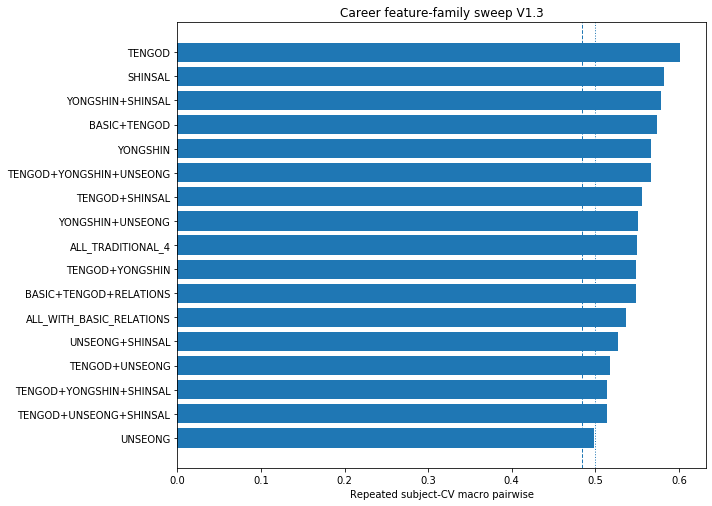

In [15]:
plot_df = summary.sort_values("pairwise_mean").copy()

fig, ax = plt.subplots(figsize=(10, max(5, len(plot_df) * 0.42)))
ax.barh(plot_df.index, plot_df["pairwise_mean"])
ax.axvline(control_metrics["macro_pairwise"], linestyle="--", linewidth=1)
ax.axvline(0.5, linestyle=":", linewidth=1)
ax.set_xlabel("Repeated subject-CV macro pairwise")
ax.set_title("Career feature-family sweep V1.3")
plt.tight_layout()
plt.show()

# How to interpret the output

### Strong evidence for adding a family

Example:

```text
TENGOD                     0.60
TENGOD + YONGSHIN          0.63
TENGOD + UNSEONG           0.61
TENGOD + SHINSAL           0.59
```

Then Yongshin is a serious next baseline candidate.

### Weak / redundant family

If adding a family changes performance by only about ±0.01 across repeated CV and LOSO, treat it as redundant until more data exists.

### Harmful complexity

If the full model is worse than TenGod alone, do not interpret that as "the classical concept is false."

It only means the **current representation + current dataset** does not improve generalization.

### Most important number

The final decision is not the highest row in the leaderboard.

It is:

> `nested_metrics["macro_pairwise"]`

If nested LOSO still beats Production Control meaningfully, the broader feature-search strategy is worth continuing.

If nested LOSO collapses toward 0.50, we are over-selecting among a small 23-subject dataset and should expand the corpus before choosing a feature stack.